<a href="https://colab.research.google.com/github/vincent-chen09/MG-Gravitational-waves/blob/main/LIGO_Data_Plots.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
%pip install gwpy



   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 20.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 295.7/295.7 kB 13.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 128.6/128.6 kB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 41.3 MB/s eta 0:00:00
  Attempting uninstall: cryptography
    Found existing installation: cryptography 43.0.3
    Uninstalling cryptography-43.0.3:
      Successfully uninstalled cryptography-43.0.3
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
pyopenssl 24.2.1 requires cryptography<44,>=41.0.5, but you have cryptography 45.0.4 which is incompatible.
pydrive2 1.21.3 requires cryptography<44, but you have cryptography 45.0.4 which is incompatible.


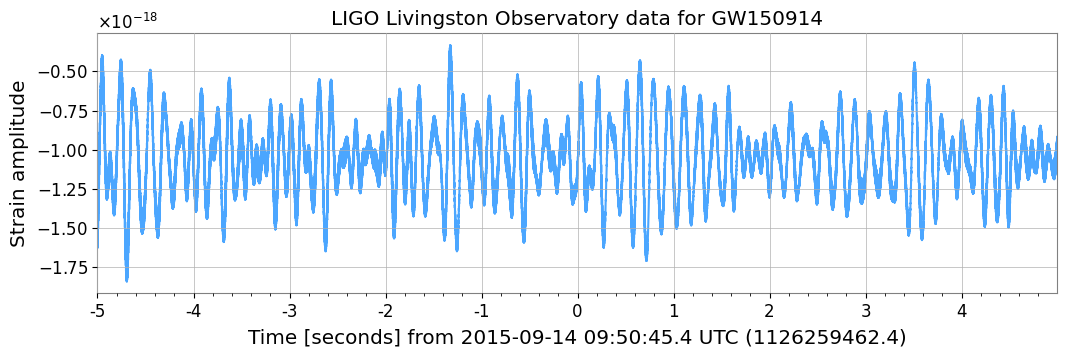

In [ ]:
from gwosc.datasets import event_gps
gps = event_gps("GW150914")
from gwpy.timeseries import TimeSeries
data = TimeSeries.fetch_open_data('L1', gps-5, gps+5)
plot = data.plot(
    title="LIGO Livingston Observatory data for GW150914",
    ylabel="Strain amplitude",
    color="gwpy:ligo-livingston",
    epoch=gps,
)
plot.show()

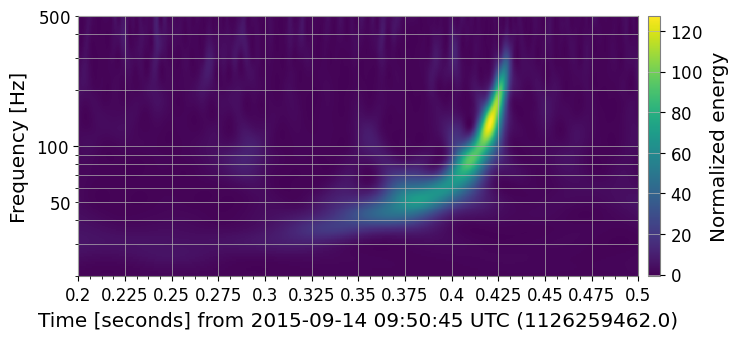

In [ ]:
from gwpy.timeseries import TimeSeries
data = TimeSeries.fetch_open_data('H1', 1126259446, 1126259478)
qspecgram = data.q_transform(outseg=(1126259462.2, 1126259462.5))
plot = qspecgram.plot(figsize=[8, 4])
ax = plot.gca()
ax.set_xscale('seconds')
ax.set_yscale('log')
ax.set_ylim(20, 500)
ax.set_ylabel('Frequency [Hz]')
ax.grid(True, axis='y', which='both')
ax.colorbar(cmap='viridis', label='Normalized energy')
plot.show()

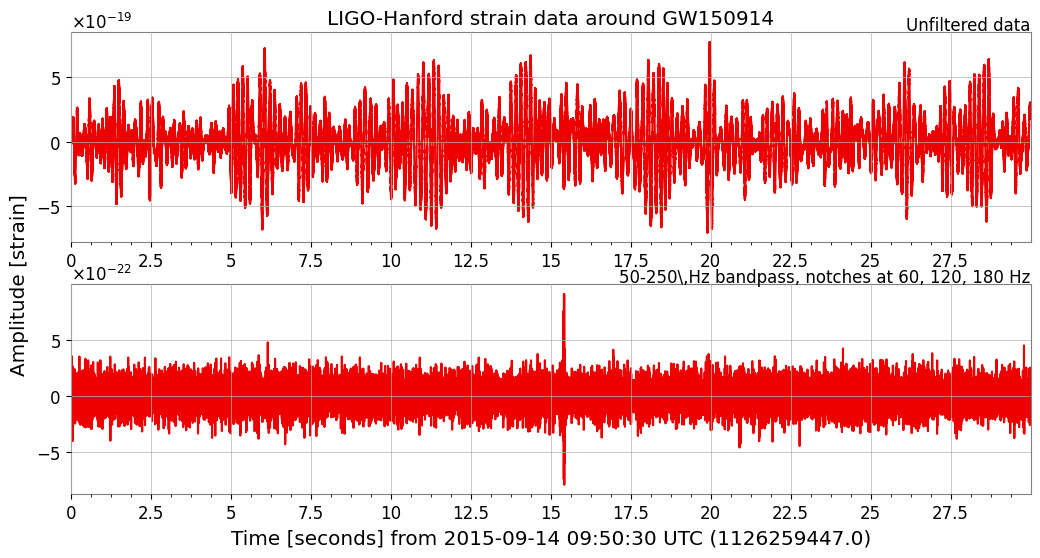

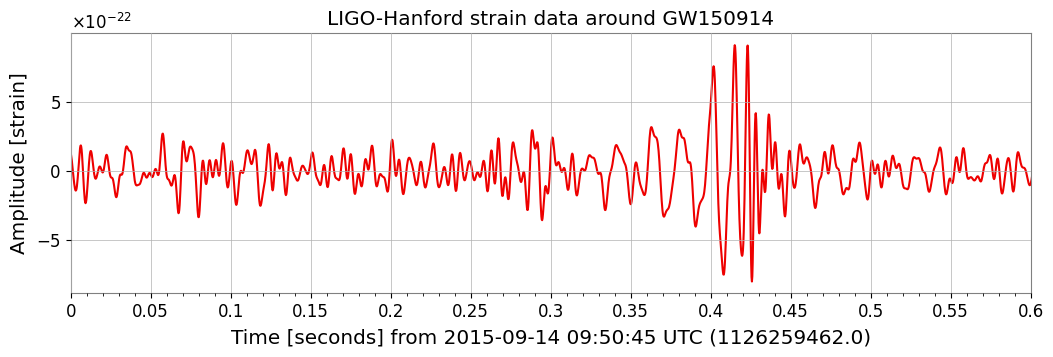

In [ ]:
from gwpy.timeseries import TimeSeries
hdata = TimeSeries.fetch_open_data('H1', 1126259446, 1126259478)
from gwpy.signal import filter_design
bp = filter_design.bandpass(50, 250, hdata.sample_rate)
notches = [filter_design.notch(line, hdata.sample_rate) for
           line in (60, 120, 180)]
zpk = filter_design.concatenate_zpks(bp, *notches)
hfilt = hdata.filter(zpk, filtfilt=True)
hdata = hdata.crop(*hdata.span.contract(1))
hfilt = hfilt.crop(*hfilt.span.contract(1))
from gwpy.plot import Plot
plot = Plot(hdata, hfilt, figsize=[12, 6], separate=True, sharex=True,
            color='gwpy:ligo-hanford')
ax1, ax2 = plot.axes
ax1.set_title('LIGO-Hanford strain data around GW150914')
ax1.text(1.0, 1.01, 'Unfiltered data', transform=ax1.transAxes, ha='right')
ax1.set_ylabel('Amplitude [strain]', y=-0.2)
ax2.set_ylabel('')
ax2.text(1.0, 1.01, r'50-250\,Hz bandpass, notches at 60, 120, 180 Hz',
         transform=ax2.transAxes, ha='right')

plot = hfilt.plot(color='gwpy:ligo-hanford')
ax = plot.gca()
ax.set_title('LIGO-Hanford strain data around GW150914')
ax.set_ylabel('Amplitude [strain]')
ax.set_xlim(1126259462, 1126259462.6)
ax.set_xscale('seconds', epoch=1126259462)


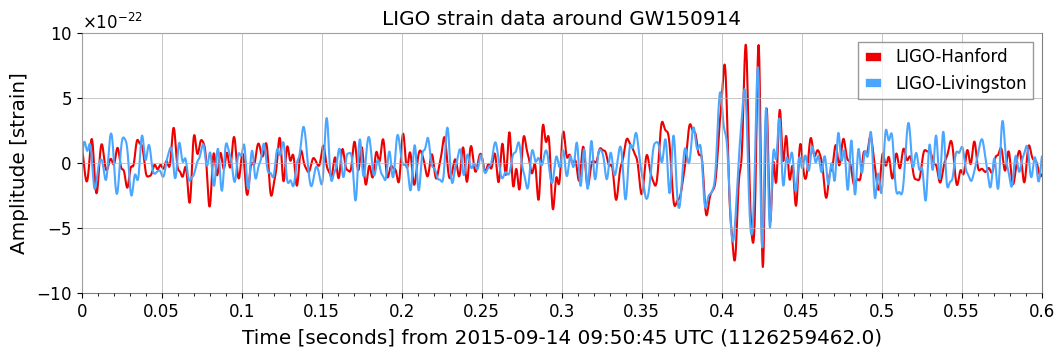

In [ ]:
ldata = TimeSeries.fetch_open_data('L1', 1126259446, 1126259478)
lfilt = ldata.filter(zpk, filtfilt=True)
lfilt.shift('6.9ms')
lfilt *= -1
plot = Plot(figsize=[12, 4])
ax = plot.gca()
ax.plot(hfilt, label='LIGO-Hanford', color='gwpy:ligo-hanford')
ax.plot(lfilt, label='LIGO-Livingston', color='gwpy:ligo-livingston')
ax.set_title('LIGO strain data around GW150914')
ax.set_xlim(1126259462, 1126259462.6)
ax.set_xscale('seconds', epoch=1126259462)
ax.set_ylabel('Amplitude [strain]')
ax.set_ylim(-1e-21, 1e-21)
ax.legend()
plot.show()


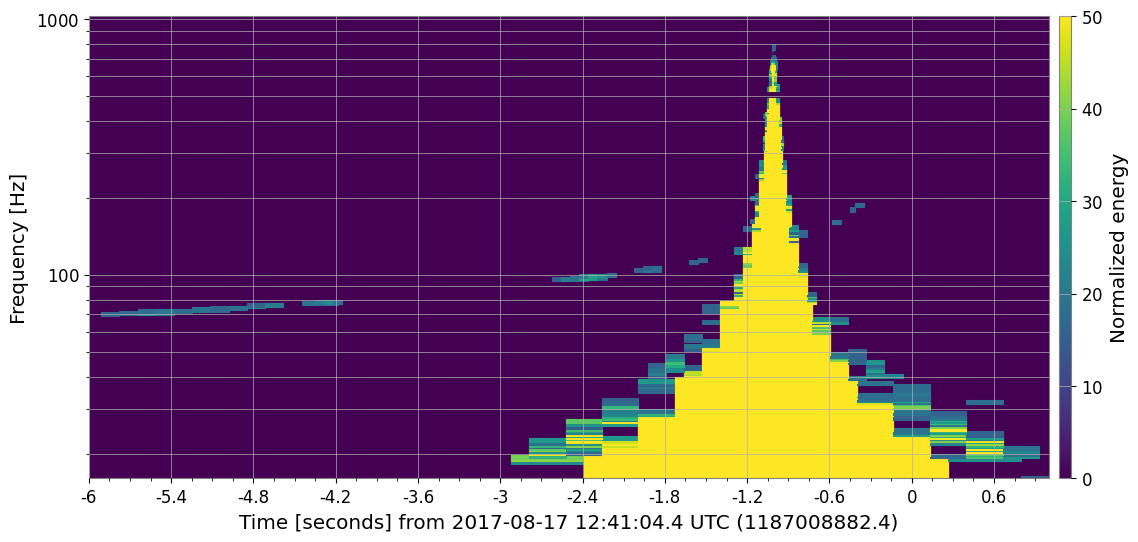

In [ ]:
from gwosc import datasets
from gwpy.timeseries import TimeSeries
gps = datasets.event_gps('GW170817')
data = TimeSeries.fetch_open_data('L1', gps-34, gps+34)
from gwpy.segments import Segment
qgram = data.q_gram(
    qrange=(4, 150),
    search=Segment(gps-0.25, gps+0.25),
    mismatch=0.35,
)
plot = qgram.tile(
    'time',
    'frequency',
    'duration',
    'bandwidth',
    color='energy',
)
ax = plot.gca()
ax.set_xscale('seconds')
ax.set_xlim(gps-6, gps+1)
ax.set_epoch(gps)
ax.set_yscale('log')
ax.set_ylim(16, 1024)
ax.set_ylabel('Frequency [Hz]')
ax.grid(True, axis='y', which='both')
from matplotlib import colormaps
cmap = colormaps['viridis']
ax.colorbar(cmap=cmap.name, label='Normalized energy', clim=[0, 50])
ax.set_facecolor(cmap(0))  # colour background to the bottom of the map
plot.show()


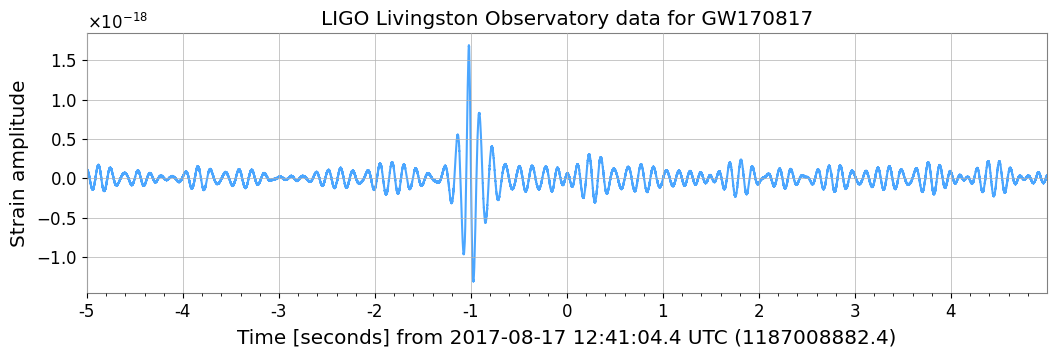

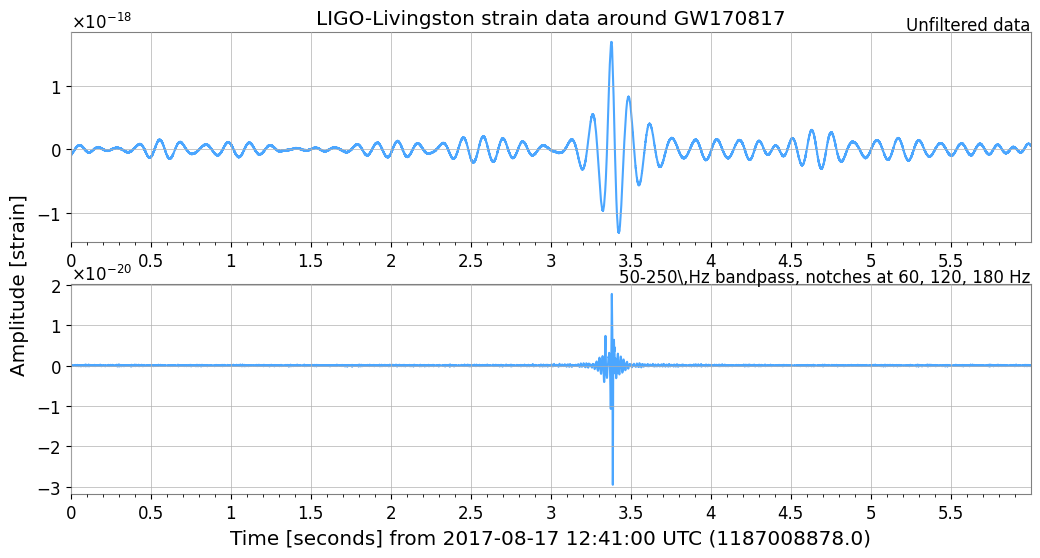

In [ ]:
gps = event_gps("GW170817")
data = TimeSeries.fetch_open_data('L1', gps-5, gps+5)
plot = data.plot(
    title="LIGO Livingston Observatory data for GW170817",
    ylabel="Strain amplitude",
    color="gwpy:ligo-livingston",
    epoch=gps,
)




hdata = TimeSeries.fetch_open_data('L1', 1187008877, 1187008885)
bp = filter_design.bandpass(50, 250, hdata.sample_rate)
notches = [filter_design.notch(line, hdata.sample_rate) for
           line in (60, 120, 180)]
zpk = filter_design.concatenate_zpks(bp, *notches)
hfilt = hdata.filter(zpk, filtfilt=True)
hdata = hdata.crop(*hdata.span.contract(1))
hfilt = hfilt.crop(*hfilt.span.contract(1))
from gwpy.plot import Plot
plot = Plot(hdata, hfilt, figsize=[12, 6], separate=True, sharex=True,
            color='gwpy:ligo-livingston')
ax1, ax2 = plot.axes
ax1.set_title('LIGO-Livingston strain data around GW170817')
ax1.text(1.0, 1.01, 'Unfiltered data', transform=ax1.transAxes, ha='right')
ax1.set_ylabel('Amplitude [strain]', y=-0.2)
ax2.set_ylabel('')
ax2.text(1.0, 1.01, r'50-250\,Hz bandpass, notches at 60, 120, 180 Hz',
         transform=ax2.transAxes, ha='right')
plot.show()

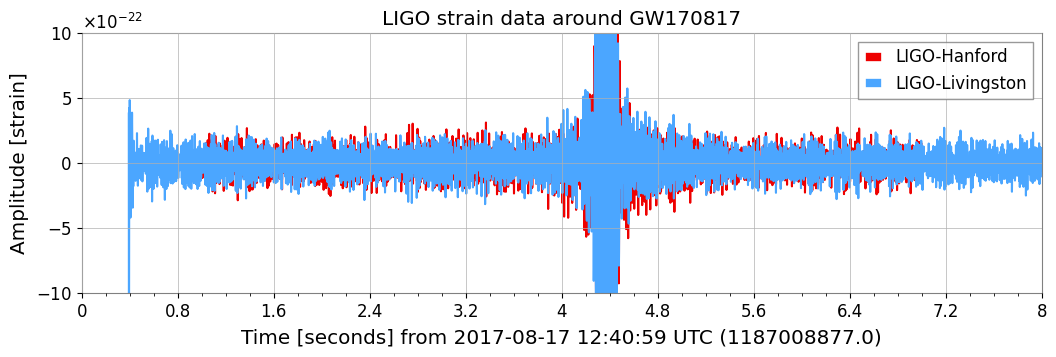

In [ ]:

ldata = TimeSeries.fetch_open_data('L1', gps-5, gps+5)
lfilt = ldata.filter(zpk, filtfilt=True)
lfilt.shift('-6.9ms')
hfilt *= -1
plot = Plot(figsize=[12, 4])
ax = plot.gca()
ax.plot(hfilt, label='LIGO-Hanford', color='gwpy:ligo-hanford')
ax.plot(lfilt, label='LIGO-Livingston', color='gwpy:ligo-livingston')
ax.set_title('LIGO strain data around GW170817')
ax.set_xlim(1187008877, 1187008885)
ax.set_xscale('seconds', epoch=1187008877)
ax.set_ylabel('Amplitude [strain]')
ax.set_ylim(-1e-21, 1e-21)
ax.legend()